In [59]:
%pip install -q pandas seaborn


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [60]:
import pandas as pd
import seaborn as sns




pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)
sns.set_style("whitegrid")

In [82]:
df = pd.read_csv("insurance.csv")

In [30]:
df.shape

(1338, 7)

In [21]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [22]:
df.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [40]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1330.000000,1338.000000,1338.000000
mean,39.207025,30.666353,1.094918,13270.422265
std,14.049960,6.103047,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.315000,0.000000,4740.287150
50%,39.000000,30.380000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1330 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [33]:
df.groupby('sex').agg({'bmi':'mean'}).round(2)

,bmi
sex,
female,30.38
male,30.92


**2. data quality check**

In [41]:
df.isnull()

,age,sex,bmi,children,smoker,region,charges
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,True,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
1333,False,False,False,False,False,False,False
1334,False,False,False,False,False,False,False
1335,False,False,False,False,False,False,False
1336,False,False,False,False,False,False,False


In [44]:
df.isnull().sum()

age         0
sex         0
bmi         8
children    0
smoker      0
region      0
charges     2
dtype: int64

In [47]:
(df.isnull().mean()*100).round(2)

age         0.00
sex         0.00
bmi         0.60
children    0.00
smoker      0.00
region      0.00
charges     0.15
dtype: float64

**Interpretation:**
This shows the percentage of missing values in each column. Here, `bmi` has about 0.60% missing values and `charges` has about 0.15%, while the other columns have no missing values.

In [49]:
df.duplicated().sum()

np.int64(1)

**Duplicate rows**
The next cell shows all rows that are duplicated in the dataset.

In [50]:
df[df.duplicated(keep=False)]

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


In [51]:
df[df.duplicated()]

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [52]:
df.nunique()

age           47
sex            2
bmi          547
children       6
smoker         2
region         4
charges     1335
dtype: int64

In [55]:
df.pivot_table(
    index='sex', 
    values='charges', 
    aggfunc='mean',
    columns= 'region'
    )

region,northeast,northwest,southeast,southwest
sex,,,,
female,12798.523941,12479.870397,13419.742764,11274.411264
male,13924.738916,12354.119575,15879.617173,13412.883576


In [62]:

 df.pivot_table(index=['sex','region'], values='charges', aggfunc=['sum','mean'])

sum      mean
                     charges   charges
sex    region                         
female northeast 2047763.831 12798.524
       northwest 2046698.745 12479.870
       southeast 2348454.984 13419.743
       southwest 1826454.625 11274.411
male   northeast 2255807.704 13924.739
       northwest 1989013.252 12354.120
       southeast 3001247.646 15879.617
       southwest 2186300.023 13412.884

In [65]:
df.pivot_table(
    index='region', 
    values='charges', 
    aggfunc='sum', 
    margins=True, 
    margins_name='Total').round(2)

,charges
region,
northeast,4303571.530
northwest,4035712.000
southeast,5349702.630
southwest,4012754.650
Total,17701740.810


,age,bmi,children,charges
count,1338.000,1330.000,1338.000,1336.000
mean,39.207,30.666,1.095,13249.806
std,14.050,6.103,1.205,12102.363
min,18.000,15.960,0.000,14.000
25%,27.000,26.315,0.000,4733.635
50%,39.000,30.380,1.000,9369.616
75%,51.000,34.694,2.000,16604.303
max,64.000,53.130,5.000,63770.428


**Handle missing values**

In [72]:
df.isnull().sum()

age         0
sex         0
bmi         8
children    0
smoker      0
region      0
charges     2
dtype: int64

In [77]:
df[df.isnull().any(axis=1)]


,age,sex,bmi,children,smoker,region,charges
3,33,male,NaN,0,no,northwest,21984.471
5,31,female,NaN,0,no,southeast,3756.622
12,23,male,NaN,0,no,southwest,1826.843
16,52,female,NaN,1,no,northeast,10797.336
17,23,male,23.845,0,no,northeast,NaN
19,30,male,NaN,0,yes,southwest,36837.467
23,34,female,31.920,1,yes,northeast,NaN
26,63,female,NaN,0,no,northeast,14451.835
34,28,male,NaN,1,yes,southwest,51194.559
36,62,female,NaN,3,no,northwest,15612.193


In [80]:
df['bmi']=df.groupby('sex')['bmi'].transform(
    lambda x: x.fillna(x.median())
)

In [81]:
df[df.isnull().any(axis=1)]

,age,sex,bmi,children,smoker,region,charges
17,23,male,23.845,0,no,northeast,NaN
23,34,female,31.920,1,yes,northeast,NaN


In [86]:
df['region'].nunique()

5

In [87]:
df['region'].unique()

<StringArray>
['southwest', 'southeast', 'northwest', 'northeast', 'SouthWest']
Length: 5, dtype: str

In [88]:
df['region'] = df['region'].str.lower().str.strip()

In [89]:
df['region'].unique()

<StringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str

In [90]:
df['region'] = df['region'].str.lower().str.strip().str.replace(' ', '_')

In [91]:
df['region'].unique()

<StringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str

**outliers**

<Axes: >

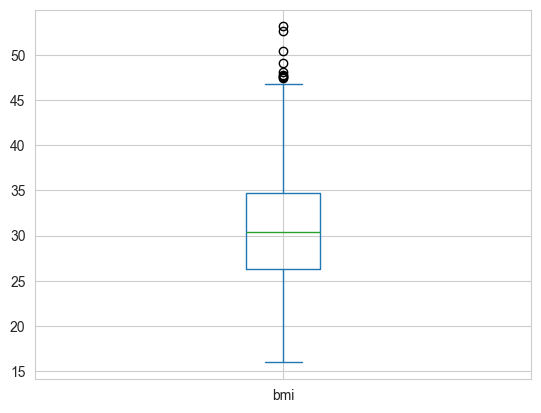

In [92]:
df['bmi'].plot(kind='box')

<Axes: >

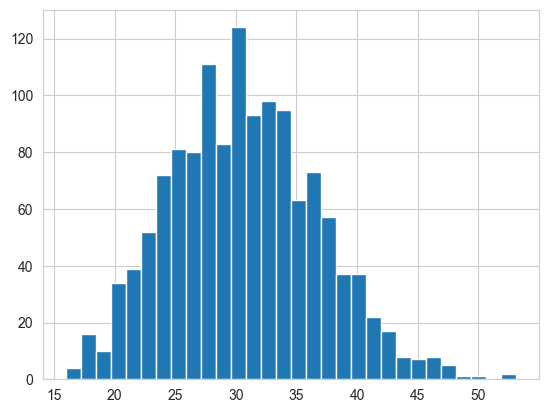

In [93]:
df['bmi'].hist(bins=30)

In [95]:
df['bmi'].corr(df['charges'])

np.float64(0.1970538304647647)

In [99]:
df['bmi'].corr(df['charges'])

np.float64(0.1970538304647647)

<Axes: xlabel='bmi', ylabel='charges'>

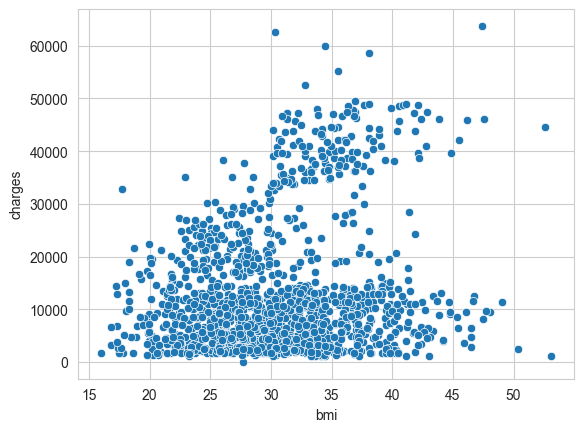

In [101]:
sns.scatterplot(x='bmi', y='charges', data=df)